# 01. create_agent로 에이전트 만들기

> LangChain V1의 핵심 함수 `create_agent` 한 줄로 ReAct 에이전트를 만들 수 있어요. 그 위에 미들웨어 데코레이터로 로직을 끼워 넣는 V1 스타일을 배웁니다.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `create_agent` 함수로 LangChain V1 에이전트를 생성하고 실행할 수 있어요
2. `system_prompt` 파라미터로 에이전트의 페르소나와 동작을 제어할 수 있어요
3. `@wrap_model_call` 미들웨어로 런타임에 모델을 동적으로 교체할 수 있어요
4. `@dynamic_prompt`로 컨텍스트 기반 동적 시스템 프롬프트를 구현할 수 있어요
5. `@before_model` / `@after_model` 훅으로 모델 호출 전후 커스텀 로직을 삽입할 수 있어요

## 사전 지식

- LangGraph `StateGraph`, `AgentState`, `add_messages` 기초 (Part 02)
- `init_chat_model`로 모델 초기화하기 (Part 02 - 02-Models)
- `07-Streaming-Steps.ipynb`에서 배운 스텝 단위 스트리밍

## 에이전트(Agent)란?

에이전트는 **LLM(추론 엔진)**과 **도구(Tool)**를 결합하여 복잡한 작업을 반복적으로 수행하는 시스템이에요. 에이전트는 주어진 작업에 대해 추론하고, 필요한 도구를 선택하며, 목표를 향해 루프를 반복해요.

> 🔑 **핵심 개념**: 에이전트를 **요리사**에 비유할 수 있어요. 요리사(LLM)는 레시피(시스템 프롬프트)를 보고, 주방 도구(Tool)를 골라 사용하며, 맛을 보고(관찰) 다시 조리(루프)하는 과정을 반복해요. `create_agent`는 이 주방 전체를 자동으로 세팅해주는 함수예요.

Part 02~04에서는 `StateGraph`로 직접 노드와 엣지를 구성했어요. Part 05부터는 LangChain V1의 `create_agent` 함수를 사용해요. 이 함수가 에이전트 루프 그래프를 자동으로 구성해줘요.

### StateGraph 직접 구성 vs create_agent 비교

| 항목 | `StateGraph` 직접 구성 (Part 02~04) | `create_agent` (Part 05~) |
|------|-------------------------------------|--------------------------|
| **코드량** | 노드, 엣지, 조건부 엣지 직접 정의 | 한 줄로 에이전트 생성 |
| **유연성** | 커스텀 그래프 구조 자유롭게 설계 | 표준 에이전트 루프 자동 구성 |
| **미들웨어** | 직접 노드에 로직 삽입 | `middleware` 파라미터로 선언적 주입 |
| **적합한 상황** | 비표준 워크플로우 | 대부분의 에이전트 개발 |

> 🎯 **강의 포인트**: V0의 `create_react_agent`는 `langgraph.prebuilt`에서 임포트했어요. V1의 `create_agent`는 `langchain.agents`에서 임포트해요. 패키지 경로가 달라진 것이 V1의 핵심 변화예요.

### 에이전트 루프(Agent Loop)

```mermaid
flowchart TD
    A["사용자 입력<br/>Human Message"] --> B["모델 노드<br/>LLM 추론"]
    B --> C{"도구 호출<br/>필요 여부"}
    C -- "도구 호출" --> D["ToolNode<br/>도구 실행"]
    D --> B
    C -- "최종 답변" --> E["최종 응답<br/>AI Message"]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef tool fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef decision fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A input
    class B process
    class D tool
    class E output
    class C decision
```

### `create_agent` 주요 파라미터

| 파라미터 | 타입 | 설명 |
|----------|------|------|
| `model` | `str` 또는 `BaseChatModel` | 추론 엔진. 문자열 또는 `init_chat_model` 인스턴스 |
| `tools` | `list` | 에이전트가 사용할 도구 목록 |
| `system_prompt` | `str` | 에이전트 페르소나·동작 정의 |
| `middleware` | `list` | 모델 호출 전후에 실행되는 훅 목록 |
| `context_schema` | `TypedDict` / `dataclass` | 런타임 컨텍스트 타입 정의 (둘 다 가능) |
| `name` | `str` | 멀티 에이전트 식별용 이름 (snake_case) |

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등 API 키를 불러와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택)
# ---------------------------------------------------
# LANGCHAIN_API_KEY가 .env에 있으면 자동으로 추적이 활성화돼요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "05-Agent-Development"

## 1. 기본 에이전트 생성

에이전트를 만드는 방법은 두 가지예요.

- **방법 1**: `create_agent("provider:model", ...)` — 문자열 직접 전달
- **방법 2**: `init_chat_model()`로 모델 인스턴스를 생성 후 전달

> 🎯 **강의 포인트**: V0의 `create_react_agent`는 `langgraph.prebuilt`에서 임포트했어요. V1의 `create_agent`는 `langchain.agents`에서 임포트해요. 패키지 경로가 달라진 것이 V1의 핵심 변화예요.

> ⚠️ **자주 하는 실수**: `tools` 파라미터에 `ToolNode` 인스턴스를 전달하면 안 돼요. `@tool` 데코레이터로 만든 함수 목록을 직접 넘겨야 해요. `ToolNode`는 `create_agent`가 내부적으로 자동 생성해요.

In [3]:
# ---------------------------------------------------
# 기본 에이전트 생성
# ---------------------------------------------------
# V1 임포트 경로: langchain.agents (V0와 다름)
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model

# 방법 1: 문자열 식별자로 바로 전달 (빠른 프로토타이핑)
# agent = create_agent("openai:gpt-4o-mini", tools=[])

# 방법 2: init_chat_model로 인스턴스 생성 후 전달 (권장)
# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성 높음)
# Anthropic 사용 시: "anthropic:claude-sonnet-4-5"
# Ollama 로컬 실행 시: "ollama:llama3"
model = init_chat_model("openai:gpt-4o-mini")

# 빈 도구 목록으로 기본 에이전트 생성
agent = create_agent(model, tools=[])

print("에이전트 생성 완료:", type(agent))

에이전트 생성 완료: <class 'langgraph.graph.state.CompiledStateGraph'>


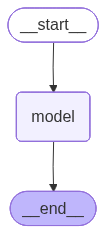

In [4]:
# 그래프 흐름: START → model → {tools_condition} → tools 또는 END
# model 노드: LLM이 추론하고 응답 또는 도구 호출을 생성해요
# 조건부 엣지: tool_calls가 있으면 tools로, 없으면 END로 분기해요
# tools 노드: 도구 실행 후 다시 model로 돌아가요 (에이전트 루프)
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [5]:
# ---------------------------------------------------
# 에이전트 실행 - invoke
# ---------------------------------------------------
# HumanMessage: 사용자가 보내는 메시지 타입
from langchain.messages import HumanMessage

result = agent.invoke(
    {"messages": [HumanMessage(content="대한민국의 수도는 어디인가요?")]}
)

# 마지막 메시지(AI 응답)를 출력해요
print(result["messages"][-1].content)

대한민국의 수도는 서울입니다.


In [6]:
# ---------------------------------------------------
# 에이전트 실행 - stream (스트리밍 출력)
# ---------------------------------------------------
# stream_mode="updates": 각 노드가 state를 업데이트할 때마다 출력
# V1에서 노드 이름이 "agent" → "model"로 변경됨
for chunk in agent.stream(
    {"messages": [HumanMessage(content="파이썬이란 무엇인가요? 한 문장으로 설명해주세요.")]},
    stream_mode="updates",
):
    for node_name, node_output in chunk.items():
        print(f"\n--- {node_name} 노드 출력 ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()  # 메시지를 보기 좋게 출력해요


--- model 노드 출력 ---
================================== Ai Message ==================================

파이썬은 코드가 간결하고 가독성이 높은 고수준 프로그래밍 언어로, 웹 개발, 데이터 분석, 인공지능 등 다양한 분야에서 널리 사용됩니다.


## 2. 모델 옵션 설정

`init_chat_model`에 추가 옵션을 전달하여 모델 동작을 세밀하게 제어할 수 있어요.

| 옵션 | 설명 | 기본값 |
|------|------|--------|
| `temperature` | 응답 다양성 (0=일관됨, 1=창의적) | 모델별 기본값 |
| `max_tokens` | 최대 생성 토큰 수 | 무제한 |
| `timeout` | 요청 타임아웃 (초) | 무제한 |

> 💡 **실무 팁**: 프로덕션 환경에서는 `timeout`을 반드시 설정하세요. 설정하지 않으면 LLM API 장애 시 요청이 무한 대기할 수 있어요. 30~60초가 일반적인 권장 값이에요.

In [7]:
# ---------------------------------------------------
# 모델 옵션 설정 예시
# ---------------------------------------------------
# temperature=0.1: 일관된 응답 생성 (사실 기반 QA에 적합)
# max_tokens=500: 응답 길이 제한으로 비용 절감
# timeout=30: 30초 초과 시 에러 발생 (프로덕션 권장)
model_with_options = init_chat_model(
    "openai:gpt-4o-mini",
    temperature=0.1,   # 낮을수록 일관된 응답
    max_tokens=500,    # 토큰 제한으로 비용 절감
    timeout=30,        # 타임아웃 설정 (초)
)

agent_with_options = create_agent(model_with_options, tools=[])

result = agent_with_options.invoke(
    {"messages": [HumanMessage(content="머신러닝을 한 문장으로 설명해주세요.")]}
)
print(result["messages"][-1].content)

머신러닝은 데이터에서 패턴을 학습하여 예측이나 결정을 자동으로 수행하는 알고리즘과 기술의 집합입니다.


## 3. system_prompt로 에이전트 페르소나 설정

`system_prompt` 파라미터(V0의 `prompt` → V1에서 이름 변경)로 에이전트의 역할과 응답 스타일을 정의해요.

> 🔑 **핵심 개념**: `system_prompt`는 모든 대화 턴에 걸쳐 일관되게 적용돼요. 에이전트가 "누구인지", "어떻게 답해야 하는지"를 규정하는 설계 문서예요.

> ⚠️ **자주 하는 실수**: V0에서 `prompt` 파라미터를 썼다면 V1에서는 `system_prompt`로 변경해야 해요. `prompt`는 V1에서 더 이상 지원하지 않아요.

In [8]:
# ---------------------------------------------------
# system_prompt로 에이전트 페르소나 설정
# ---------------------------------------------------
# system_prompt: V1에서 V0의 prompt 파라미터를 대체해요
model = init_chat_model("openai:gpt-4o-mini")

agent_with_prompt = create_agent(
    model,
    system_prompt=(
        "당신은 친절한 한국어 AI 튜터예요. "
        "모든 답변은 한국어로 간결하게 2~3문장으로 제공해요. "
        "기술 용어는 첫 등장 시 한글(영어) 형태로 병기해요."
    ),
)

result = agent_with_prompt.invoke(
    {"messages": [HumanMessage(content="LLM이 뭐예요?")]}
)
print(result["messages"][-1].content)

LLM은 대규모 언어 모델(Large Language Model)의 약자입니다. LLM은 방대한 양의 텍스트 데이터를 기반으로 학습하여 자연어 처리(NLP) 작업을 수행하는 인공지능 모델입니다. 이를 통해 텍스트 생성, 번역, 질문 응답 등 다양한 작업을 수행할 수 있습니다.


In [9]:
# ============================================================
# 실습 해설: system_prompt를 수정하여 나만의 에이전트를 만들어보세요
# 힌트: system_prompt에 "항상 bullet point로 답변하세요" 또는
#        "emoji를 3개 이상 사용하세요" 같은 지시를 추가해보세요
# 예상 결과: 에이전트의 응답 스타일이 system_prompt에 따라 달라져요
# ============================================================
my_agent = create_agent(
    model,
    system_prompt="여기에 나만의 시스템 프롬프트를 작성해보세요!",
)

result = my_agent.invoke(
    {"messages": [HumanMessage(content="딥러닝의 핵심 원리를 알려주세요.")]}
)
print(result["messages"][-1].content)

딥러닝의 핵심 원리는 인공신경망(Artificial Neural Networks)으로, 이는 인간의 뇌 구조를 모방하여 데이터를 처리하고 학습하는 방법입니다. 다음은 딥러닝의 주요 원리입니다:

1. **신경망 구조**: 딥러닝 모델은 입력층, 은닉층, 출력층으로 구성된 여러 개의 층(layer)으로 이루어져 있습니다. 각 층은 노드(node) 또는 뉴런(neuron)으로 구성되어 있으며, 이들은 서로 연결되어 있습니다.

2. **비선형성**: 딥러닝 모델에서는 활성화 함수(activation function)를 사용하여 비선형성을 도입합니다. 이는 네트워크가 복잡한 패턴을 학습할 수 있도록 도와줍니다. 대표적인 활성화 함수로는 ReLU, Sigmoid, Tanh 등이 있습니다.

3. **가중치와 편향**: 각 연결은 가중치(weight)를 가지며, 이는 학습 과정에서 조정됩니다. 또한, 각 뉴런에는 편향(bias) 값이 있어 모델이 더 유연하게 데이터를 처리할 수 있도록 합니다.

4. **역전파 알고리즘**: 딥러닝 모델은 학습 과정에서 예측값과 실제값의 오차를 계산해 이 오차를 최소화하도록 가중치를 조정합니다. 이를 위해 역전파(backpropagation) 알고리즘을 사용하여 오차를 네트워크의 각 가중치에 대해 전파하고 업데이트합니다.

5. **대량의 데이터와 컴퓨팅 파워**: 딥러닝 모델은 대규모 데이터셋에서 효과적으로 학습할 수 있으며, GPU 같은 강력한 하드웨어를 이용해 높은 연산 성능을 활용합니다.

6. **전이 학습**: 사전 학습된 모델을 다른 유사한 문제에 적용하는 기법으로, 이를 통해 학습 효율을 높이고, 데이터가 부족한 상황에서도 좋은 성능을 낼 수 있습니다.

이러한 원리들 덕분에 딥러닝은 이미지 인식, 자연어 처리, 자율주행차 등 다양한 분야에서 혁신적인 성과를 이루고 있습니다.


## 4. 동적 모델 선택: @wrap_model_call

런타임 상태나 컨텍스트에 따라 모델을 교체해야 할 때 `@wrap_model_call` 미들웨어를 사용해요.

> **왜 동적 모델 선택이 필요할까요?** 모든 요청에 고성능 모델을 쓰면 비용이 치솟고, 저렴한 모델만 쓰면 복잡한 질문에 품질이 떨어져요. 동적 모델 선택은 **요청 특성에 따라 비용과 품질의 균형**을 자동으로 맞춰줘요. 마치 레스토랑에서 간단한 음료는 셀프 서비스로, 코스 요리는 전담 셰프가 담당하는 것과 같아요.

```mermaid
flowchart LR
    A["요청 수신<br/>ModelRequest"] --> B["wrap_model_call<br/>미들웨어"]
    B --> C{"상태 분석<br/>(메시지 수, 복잡도 등)"}
    C -- "단순" --> D["경량 모델<br/>gpt-4o-mini"]
    C -- "복잡" --> E["고성능 모델<br/>gpt-4o"]
    D --> F["handler 호출<br/>실제 LLM 실행"]
    E --> F
    F --> G["응답 반환<br/>ModelResponse"]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef decision fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A input
    class B,D,E,F process
    class G output
    class C decision
```

> ⚠️ **자주 하는 실수**: `request.model = new_model` 직접 할당은 deprecated예요. 반드시 `request.override(model=new_model)`을 사용해요. `override()`는 불변 객체처럼 새로운 `ModelRequest`를 반환해요.

### ModelRequest 주요 속성

| 속성 | 설명 |
|------|------|
| `model` | 사용할 `BaseChatModel` 인스턴스 |
| `system_prompt` | 시스템 프롬프트 (선택) |
| `messages` | 대화 메시지 리스트 (시스템 제외) |
| `tools` | 사용 가능한 도구 리스트 |
| `tool_choice` | 도구 선택 설정 |
| `state` | 현재 `AgentState` (messages 포함) |
| `runtime` | 런타임 정보 (context, store 접근) |
| `model_settings` | 추가 모델 설정 dict |

In [10]:
# ---------------------------------------------------
# 동적 모델 선택: 메시지 길이 기반 라우팅
# ---------------------------------------------------
# wrap_model_call: 모델 호출을 감싸는 미들웨어 데코레이터
# ModelRequest: 모델 호출 정보를 담는 데이터 클래스
# ModelResponse: 모델 응답 정보를 담는 데이터 클래스
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse

# 두 가지 모델 준비 (비용 vs 성능 트레이드오프)
lightweight_model = init_chat_model("openai:gpt-4o-mini")  # 짧은 질문용 경량 모델
advanced_model = init_chat_model("openai:gpt-4o-mini")     # 긴 질문용 고성능 모델
# 실제 환경에서는: init_chat_model("openai:gpt-4o")


@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler) -> ModelResponse:
    """마지막 메시지 길이에 따라 모델을 동적으로 선택해요"""
    # 마지막 메시지 내용의 길이를 기준으로 모델 선택
    last_message_content = request.state["messages"][-1].content
    char_count = len(last_message_content)
    print(f"입력 길이: {char_count}자")

    if char_count > 20:
        # 긴 질문 → 고성능 모델 + 상세 답변 유도
        new_request = request.override(
            model=advanced_model,
            system_prompt="상세하고 구조적으로 답변해요. 예시를 포함해요.",
        )
        # 고성능 모델 선택 (긴 질문)
    else:
        # 짧은 질문 → 경량 모델 + 간결한 답변 유도
        new_request = request.override(
            model=lightweight_model,
            system_prompt="한 문장으로 간결하게 답변해요.",
        )
        # 경량 모델 선택 (짧은 질문)

    return handler(new_request)


agent_dynamic = create_agent(
    model=lightweight_model,       # 기본 모델 (미들웨어가 런타임에 교체)
    tools=[],
    middleware=[dynamic_model_selection],  # 미들웨어 등록
)

# 동적 모델 선택 에이전트 생성 완료

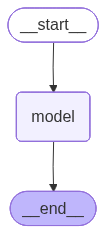

In [11]:
# 그래프 흐름: START → model → END
# model 노드: wrap_model_call 미들웨어가 메시지 길이에 따라 모델을 동적으로 선택해요
# 도구가 없으므로 model → END로 직행해요
from IPython.display import Image, display
display(Image(agent_dynamic.get_graph().draw_mermaid_png()))

In [26]:
# ---------------------------------------------------
# 짧은 질문 테스트 (20자 미만 → 경량 모델)
# ---------------------------------------------------
# === 짧은 질문 ===
result = agent_dynamic.invoke(
    {"messages": [HumanMessage(content="AI란?")]}
)
print(result["messages"][-1].content)
result

입력 길이: 4자
AI(인공지능)는 인간의 지능을 모방하여 학습, 문제 해결, 의사결정 등을 수행하는 컴퓨터 시스템입니다.


{'messages': [HumanMessage(content='AI란?', additional_kwargs={}, response_metadata={}, id='84bd31f3-8117-4bdf-a42a-fc2170b59944'),
  AIMessage(content='AI(인공지능)는 인간의 지능을 모방하여 학습, 문제 해결, 의사결정 등을 수행하는 컴퓨터 시스템입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 26, 'total_tokens': 58, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0ad65e3318', 'id': 'chatcmpl-Dkfzx1AjJUnzvjRnTFAK6gs6ZLll6', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e7146-5be4-7ee1-a70f-56c31e6073a7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 26, 'output_tokens': 32, 'total_tokens': 58, 'input_token_details': {'audio': 0, 'cache_read':

In [13]:
# ---------------------------------------------------
# 긴 질문 테스트 (20자 이상 → 고성능 모델)
# ---------------------------------------------------
# === 긴 질문 ===
result = agent_dynamic.invoke(
    {"messages": [HumanMessage(content="딥러닝과 머신러닝의 차이점과 각각의 장단점을 설명해주세요.")]}
)
print(result["messages"][-1].content)

입력 길이: 32자
딥러닝(Deep Learning)과 머신러닝(Machine Learning)은 인공지능(AI)의 두 주요 분야로, 각기 다른 방법론과 특성을 가지고 있습니다. 이 둘의 차이점과 장단점을 아래와 같은 구조로 설명하겠습니다.

### 1. 정의

- **머신러닝 (Machine Learning)**
  - 머신러닝은 데이터를 통해 학습하고 패턴을 인식하여 예측 및 결정을 내리는 알고리즘과 기술을 의미합니다. 여기에는 회귀 분석, 결정트리, SVM(Support Vector Machine), k-최근접 이웃(k-NN) 등 다양한 기법이 포함됩니다.

- **딥러닝 (Deep Learning)**
  - 딥러닝은 머신러닝의 한 하위 분야로, 인공신경망(Artificial Neural Networks)을 기반으로 한 모델들을 사용하여 데이터에서 특징(feature)을 자동으로 추출하고, 복잡한 문제를 해결합니다. 특히 다층 구조의 신경망을 통해 더욱 고도화된 학습을 진행합니다.

### 2. 차이점

| 구분       | 머신러닝                         | 딥러닝                             |
|------------|----------------------------------|------------------------------------|
| **데이터 요구량** | 상대적으로 적은 데이터로도 학습 가능 | 대량의 데이터 필요 (특히 고차원 데이터) |
| **특징 추출**    | 특징 추출을 수동으로 수행해야 함 | 자동으로 특징을 추출하는 능력 보유    |
| **모델 복잡성**   | 간단한 모델에서 복잡한 모델까지 다양 | 일반적으로 매우 복잡한 모델 사용    |
| **해석 가능성**   | 비교적 해석 가능성이 높음       | 모델의 복잡성으로 인해 해석이 어려움  |
| **계산 자원**    | 일반적으로 적은 계산 자원 소모   | 대량의 계산 자원 요구 (GPU/TPU 필

## 5. 동적 시스템 프롬프트: @dynamic_prompt

`system_prompt` 문자열은 고정값이에요. 런타임에 컨텍스트에 따라 다른 프롬프트를 적용하려면 `@dynamic_prompt` 미들웨어를 사용해요.

**동작 흐름:**
1. 에이전트 호출 시 `context` 파라미터로 컨텍스트 전달
2. `@dynamic_prompt` 함수가 `request.runtime.context`로 컨텍스트 접근
3. 컨텍스트 값에 따라 다른 시스템 프롬프트 반환

> 🔑 **핵심 개념**: `context_schema`는 `TypedDict`, `dataclass`, Pydantic 모델 모두로 정의할 수 있어요. 이 노트북은 `TypedDict`를 쓰지만, `02-Tools-V1.ipynb`와 `05-Runtime-Context.ipynb`에서는 `dataclass`를 사용해요. 어떤 방식이든 `create_agent`에 `context_schema`를 전달하면 IDE에서 타입 검사를 받을 수 있어요. (출처: [Structured output 공식 문서](https://docs.langchain.com/oss/python/langchain/structured-output.md))

> 💡 **실무 팁**: 동적 프롬프트는 다국어 서비스, A/B 테스트, 사용자 역할 기반 응답에 아주 유용해요. 코드를 수정하지 않고도 컨텍스트만 바꿔서 에이전트 동작을 제어할 수 있어요.

In [ ]:
# ---------------------------------------------------
# 동적 시스템 프롬프트 설정
# ---------------------------------------------------
# TypedDict: context_schema 정의에 사용 (Pydantic 불가)
# dynamic_prompt: 런타임 컨텍스트 기반 프롬프트 생성 데코레이터
from typing import TypedDict
from langchain.agents.middleware import dynamic_prompt, ModelRequest


# 컨텍스트 스키마 정의: 에이전트 호출 시 전달할 데이터 구조
class ResponseContext(TypedDict):
    format: str    # "default" | "sns" | "article"
    language: str  # "ko" | "en"
    max_length: int


@dynamic_prompt
def format_aware_prompt(request: ModelRequest) -> str:
    """컨텍스트에 따라 응답 형식을 동적으로 설정해요"""
    # runtime.context에서 전달된 컨텍스트를 읽어요
    ctx = request.runtime.context or {}
    fmt = ctx.get("format", "default")
    lang = ctx.get("language", "ko")
    max_len = ctx.get("max_length", 200)

    # 언어 설정
    lang_instruction = "한국어로" if lang == "ko" else "in English"

    # 형식에 따라 다른 시스템 프롬프트 반환
    if fmt == "sns":
        return (
            f"{lang_instruction} SNS 게시글 형식으로 답변해요. "
            f"이모지를 적절히 사용하고 {max_len}자 이내로 작성해요."
        )
    elif fmt == "article":
        return (
            f"{lang_instruction} 뉴스 기사 형식으로 작성해요. "
            f"제목, 본문 구조를 갖추고 {max_len}자 이내로 작성해요."
        )
    else:  # default
        return (
            f"{lang_instruction} 간결하게 답변해요. "
            f"{max_len}자 이내로 핵심만 설명해요."
        )


# context_schema를 create_agent에 등록
agent_dynamic_prompt = create_agent(
    model=init_chat_model("openai:gpt-4o-mini"),
    middleware=[format_aware_prompt],
    context_schema=ResponseContext,  # 타입 검사용 스키마
)

# 동적 프롬프트 에이전트 생성 완료

In [15]:
# ---------------------------------------------------
# 동적 프롬프트 테스트 - SNS 형식
# ---------------------------------------------------
# invoke에 context 파라미터로 컨텍스트 전달
# === SNS 형식 ===
result = agent_dynamic_prompt.invoke(
    {"messages": [HumanMessage(content="AI가 우리 일상을 바꾸고 있어요.")]},
    context=ResponseContext(format="sns", language="ko", max_length=100),
)
print(result["messages"][-1].content)

💡 AI가 우리의 삶을 더 편리하게 만들어주고 있어요! 스마트홈부터 개인화된 추천까지, 미래가 기대돼요! 🚀✨ #AI #미래기술


In [16]:
# ---------------------------------------------------
# 동적 프롬프트 테스트 - 뉴스 기사 형식
# ---------------------------------------------------
# === 뉴스 기사 형식 ===
result = agent_dynamic_prompt.invoke(
    {"messages": [HumanMessage(content="AI가 우리 일상을 바꾸고 있어요.")]},
    context=ResponseContext(format="article", language="ko", max_length=500),
)
print(result["messages"][-1].content)

**제목: AI, 우리의 일상 속으로 빠르게 침투하다**

최근 몇 년간 인공지능(AI) 기술이 급속도로 발전하면서 우리의 일상생활에 큰 변화를 가져오고 있다. 스마트폰에서부터 가정용 기기, 자동차에 이르기까지 AI는 이제 필수적인 요소로 자리잡았다.

우선, AI는 가정에서의 편리함을 크게 증대시켰다. 음성 인식 스피커를 이용한 가사 검색이나, 스마트 홈 시스템을 통해 조명과 온도를 자동 조절할 수 있어 많은 사람들이 일상의 효율성을 즐기고 있다. 또한, AI 비서의 도움으로 일정 관리나 정보 검색이 간편해져, 바쁜 현대인들에게 큰 도움이 되고 있다.

또한, 기업에서도 AI의 활용이 증가하고 있다. 고객 서비스에 AI 챗봇을 도입함으로써 24시간 대응이 가능해졌으며, 데이터 분석을 통한 마케팅 전략 수립이 보다 정교해지고 있다. 이로 인해 기업의 생산성이 향상되고, 고객 만족도가 높아지는 긍정적인 결과를 보여주고 있다.

하지만 AI 기술의 발전이 가져오는 윤리적 문제와 일자리 감소에 대한 우려도 여전히 존재한다. 전문가들은 AI와 인간의 협업이 중요하다고 강조하며, 지속적인 교육과 새로운 직업 창출이 필요하다고 입을 모은다.

AI가 우리의 일상을 변화시키고 있는 지금, 우리는 이 기술을 올바르게 활용하고, 사회적인 문제들을 함께 해결해 나가야 할 시점에 있다.


## 6. 미들웨어 훅: @before_model / @after_model

> 이 절은 Part 06 미들웨어 단원의 **맛보기**예요. 여기서는 `before_model`/`after_model` 두 지점만 써보고, 전체 후크 지도와 노드/랩 스타일 구분은 `06_Middleware/01-Middleware-Basics.ipynb`에서 정리해요.

`@wrap_model_call`이 모델 호출 요청 자체를 수정한다면, `@before_model`과 `@after_model`은 에이전트 상태(state)에 접근해서 전처리·후처리를 해요.

| 데코레이터 | 실행 시점 | 반환값 | 주요 용도 |
|------------|-----------|--------|----------|
| `@before_model` | 모델 호출 직전 | `dict` (state 업데이트) 또는 `None` | 쿼리 재작성, 메시지 전처리 |
| `@after_model` | 모델 호출 직후 | `dict` (state 업데이트) 또는 `None` | 로깅, 응답 후처리 |

> 🎯 **강의 포인트**: `@before_model`에서 `dict`를 반환하면 그 내용이 `AgentState`에 업데이트돼요. `messages` 키를 반환하면 `add_messages` 리듀서가 적용되어 **메시지가 추가**돼요 (기존 메시지를 교체하려면 동일한 `id`를 가진 메시지를 반환하거나 `RemoveMessage`로 명시적으로 제거해야 해요). `None`을 반환하면 state를 변경하지 않아요.

> 💡 **실무 팁**: 쿼리 재작성(Query Rewriting)은 RAG 시스템에서 검색 품질을 높이는 핵심 기법이에요. `@before_model`에서 사용자 입력을 더 명확한 형태로 변환하면 LLM의 답변 품질도 올라가요. 아래 예제는 새 `HumanMessage`를 추가(append)하는 간단한 방식이고, 마지막 메시지가 재작성본이므로 모델이 최신 쿼리를 우선적으로 참고해요.

In [17]:
# ---------------------------------------------------
# @before_model / @after_model 훅 정의
# ---------------------------------------------------
# before_model: 모델 호출 전 실행, 쿼리 재작성에 활용
# after_model: 모델 호출 후 실행, 로깅·후처리에 활용
# AgentState: 에이전트 상태 타입 (messages 포함)
# Runtime: 런타임 정보 (context, store 접근)
from langchain.agents.middleware import before_model, after_model, AgentState
from langgraph.runtime import Runtime
from typing import Any


@before_model
def query_rewriter(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """모델 호출 전 마지막 메시지를 더 명확한 형태로 재작성해요"""
    last_message = state["messages"][-1]
    original_query = last_message.content
    print(f"[before_model] 원본 쿼리: {original_query}")

    # 간단한 키워드 쿼리를 자연어 질문으로 변환
    # 실제 환경에서는 LLM을 사용해 더 정교하게 재작성할 수 있어요
    if len(original_query) < 10 and "?" not in original_query:
        # 짧은 키워드는 질문 형태로 변환
        rewritten = f"{original_query}에 대해 상세히 설명해주세요."
        print(f"[before_model] 재작성 쿼리: {rewritten}")
        # HumanMessage 재생성해서 messages 업데이트
        return {"messages": [HumanMessage(content=rewritten)]}

    # 변경 불필요 → None 반환
    return None


@after_model
def response_logger(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """모델 호출 후 대화 상태를 로깅해요"""
    total_msgs = len(state["messages"])
    last_response = state["messages"][-1].content
    print(f"[after_model] 총 메시지 수: {total_msgs}개")
    print(f"[after_model] 응답 길이: {len(last_response)}자")
    # 상태 변경 없음 → None 반환
    return None


agent_with_hooks = create_agent(
    model=init_chat_model("openai:gpt-4o-mini"),
    middleware=[query_rewriter, response_logger],  # 순서대로 적용
)

# 훅 미들웨어 에이전트 생성 완료

In [18]:
# ---------------------------------------------------
# 훅 미들웨어 테스트 - 짧은 키워드 입력
# ---------------------------------------------------
# 짧은 키워드: before_model에서 질문 형태로 재작성됨
# === 짧은 키워드 입력 ===
result = agent_with_hooks.invoke(
    {"messages": [HumanMessage(content="강화학습")]}
)
# 최종 응답:
print(result["messages"][-1].content)

[before_model] 원본 쿼리: 강화학습
[before_model] 재작성 쿼리: 강화학습에 대해 상세히 설명해주세요.
[after_model] 총 메시지 수: 3개
[after_model] 응답 길이: 1819자
강화학습(Reinforcement Learning, RL)은 기계 학습의 한 분야로, 에이전트(agent)가 환경(environment)과 상호작용하며 주어진 작업(task)을 수행하는 방법을 배우는 알고리즘입니다. 에이전트는 상태(state)와 행동(action)을 통해 보상(reward)을 최대화하는 방법을 학습합니다. 강화학습의 핵심 구성 요소는 다음과 같습니다.

### 1. 구성 요소
- **에이전트(Agent)**: 환경에서 행동을 취하고 학습하는 주체입니다.
- **환경(Environment)**: 에이전트가 상호작용하는 외부 시스템입니다. 에이전트의 행동에 따라 상태가 변하고 보상이 주어집니다.
- **상태(State)**: 환경의 현재 상태를 나타내며, 에이전트는 이 상태를 기반으로 행동을 결정합니다.
- **행동(Action)**: 에이전트가 취할 수 있는 선택지입니다. 각 행동은 환경에 영향을 미치고, 그에 따라 새로운 상태와 보상이 발생합니다.
- **보상(Reward)**: 에이전트가 특정 행동을 취했을 때 환경으로부터 받는 피드백입니다. 에이전트는 이 보상을 통해 자신의 행동을 평가하고 학습합니다.

### 2. 학습 과정
강화학습의 학습 과정은 다음과 같습니다:

1. **초기화**: 에이전트는 초기 상태에서 시작합니다.
2. **행동 선택**: 에이전트는 현재 상태를 기반으로 행동을 선택합니다. 이 선택은 탐사(exploration)와 활용(exploitation) 사이의 균형을 유지해야 합니다. 탐사는 새로운 행동을 시도하는 것이고, 활용은 이미 배운 것을 기반으로 최적 행동을 취하는 것입니다.
3. **상태 전이**: 선택한 행동을 수행하면 환경의 상태가 변화하고 그에 대한 보상이 주어집니다.
4. **보상 수

In [19]:
# ---------------------------------------------------
# 훅 미들웨어 테스트 - 충분히 긴 자연어 질문
# ---------------------------------------------------
# 긴 질문: before_model에서 재작성 없이 그대로 전달됨
# === 자연어 질문 (재작성 생략) ===
result = agent_with_hooks.invoke(
    {"messages": [HumanMessage(content="파이썬에서 리스트와 딕셔너리의 차이가 뭔가요?")]}
)
# 최종 응답:
print(result["messages"][-1].content)

[before_model] 원본 쿼리: 파이썬에서 리스트와 딕셔너리의 차이가 뭔가요?
[after_model] 총 메시지 수: 2개
[after_model] 응답 길이: 1396자
파이썬에서 리스트(list)와 딕셔너리(dictionary)는 모두 데이터를 저장하기 위한 컬렉션(data structure)입니다. 하지만 이 두 자료형은 여러 면에서 다릅니다. 아래에서 주요 차이점을 설명하겠습니다.

### 리스트 (List)
1. **순서 유지**: 리스트는 순서가 있는 컬렉션입니다. 즉, 저장된 요소들은 인덱스를 통해 접근할 수 있으며, 인덱스는 0부터 시작합니다.
   
   ```python
   my_list = [10, 20, 30, 40]
   print(my_list[1])  # 출력: 20
   ```

2. **변경 가능**: 리스트는 가변(mutable) 자료형으로, 요소를 추가, 삭제, 수정할 수 있습니다.

   ```python
   my_list.append(50)  # 50 추가
   my_list[0] = 15     # 첫 번째 요소 변경
   ```

3. **중복 허용**: 리스트는 중복된 요소를 허용합니다.

   ```python
   my_list = [1, 2, 2, 3]
   ```

4. **사용 용도**: 주로 순서가 중요한 데이터를 저장할 때 사용됩니다.

### 딕셔너리 (Dictionary)
1. **키-값 쌍**: 딕셔너리는 키(key)와 값(value)의 쌍으로 이루어진 컬렉션입니다. 키는 고유해야 하며, 이를 통해 값을 조회합니다.

   ```python
   my_dict = {'name': 'Alice', 'age': 25}
   print(my_dict['name'])  # 출력: Alice
   ```

2. **변경 가능**: 딕셔너리 또한 가변(mutable) 자료형으로, 키-값 쌍을 추가, 삭제, 수정할 수 있습니다.

   ```python
   my_dict['age'] = 26  # 

## 7. 클래스 기반 미들웨어와 재시도 로직

> 📌 **심화(선택)**: 이 절(§7)과 다음 절(§8)은 미들웨어 심화 내용이에요. 처음 보는 경우 가볍게 훑고 넘어가도 괜찮아요. 미들웨어는 `06_Middleware` 단원에서 본격적으로 다뤄요.

복잡한 미들웨어 로직은 클래스로 구조화하거나, `@wrap_model_call`로 재시도 로직을 구현할 수 있어요.

> 🔑 **핵심 개념**: `AgentMiddleware`를 상속한 클래스는 `state_schema`로 커스텀 상태를 정의할 수 있어요. 미들웨어가 추가적인 상태 필드를 필요로 할 때 사용해요.

> 💡 **실무 팁**: LLM API 호출은 네트워크 오류, 속도 제한(rate limit), 서버 과부하 등으로 일시적으로 실패할 수 있어요. `@wrap_model_call`로 재시도 로직을 미들웨어로 캡슐화하면 에이전트 코드가 깔끔해지고 재사용성이 높아져요.

In [20]:
# ---------------------------------------------------
# 재시도 로직 미들웨어
# ---------------------------------------------------
# wrap_model_call: 모델 호출 전체를 감싸는 미들웨어
# 재시도 로직을 미들웨어로 캡슐화하면 에이전트 코드가 깔끔해져요
from typing import Callable
import time


@wrap_model_call
def retry_on_failure(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    """모델 호출 실패 시 최대 3회 재시도해요"""
    max_retries = 3
    last_error = None

    for attempt in range(max_retries):
        try:
            return handler(request)
        except Exception as e:
            last_error = e
            if attempt < max_retries - 1:
                wait_seconds = 2 ** attempt  # 지수 백오프: 1초, 2초
                print(f"[재시도 {attempt + 1}/{max_retries}] 오류: {e} → {wait_seconds}초 후 재시도")
                time.sleep(wait_seconds)
            else:
                print(f"[실패] 최대 재시도 횟수 초과: {e}")
    raise last_error


agent_with_retry = create_agent(
    model=init_chat_model("openai:gpt-4o-mini"),
    middleware=[retry_on_failure],
)

# 재시도 미들웨어 에이전트 생성 완료

In [21]:
# ---------------------------------------------------
# 클래스 기반 미들웨어: 커스텀 상태 스키마
# ---------------------------------------------------
# AgentMiddleware: 클래스 기반 미들웨어 베이스 클래스
# state_schema: 미들웨어가 추가하는 커스텀 상태 필드 정의
from langchain.agents import AgentState
from langchain.agents.middleware import AgentMiddleware


# 커스텀 상태 스키마: AgentState를 확장
class TrackedState(AgentState):
    call_count: int  # 모델 호출 횟수 추적


class CallCountMiddleware(AgentMiddleware):
    """모델 호출 횟수를 state에 기록하는 미들웨어예요"""
    state_schema = TrackedState  # 커스텀 상태 등록
    tools = []

    def before_model(self, state: TrackedState, runtime: Runtime) -> dict[str, Any] | None:
        # 현재 호출 횟수 증가
        current_count = state.get("call_count", 0)
        print(f"[CallCountMiddleware] 모델 호출 횟수: {current_count + 1}")
        return {"call_count": current_count + 1}


agent_tracked = create_agent(
    model=init_chat_model("openai:gpt-4o-mini"),
    middleware=[CallCountMiddleware()],  # 클래스 인스턴스 전달
)

# TrackedState 사용: messages와 call_count 모두 포함
result = agent_tracked.invoke(
    {
        "messages": [HumanMessage(content="안녕하세요!")],
        "call_count": 0,  # 초기값
    }
)

print(f"최종 호출 횟수: {result.get('call_count', 'N/A')}")
print(f"응답: {result['messages'][-1].content}")

[CallCountMiddleware] 모델 호출 횟수: 1
최종 호출 횟수: 1
응답: 안녕하세요! 어떻게 도와드릴까요?


## 8. 미들웨어 체이닝 (심화·선택)

여러 미들웨어를 `middleware` 리스트에 순서대로 등록하면 체인으로 실행돼요. 미들웨어 체이닝은 **양파 껍질** 구조라고 생각하면 이해하기 쉬워요 -- 요청은 바깥에서 안쪽으로 들어가고, 응답은 안쪽에서 바깥으로 나와요.

```
요청 → middleware[0] → middleware[1] → middleware[2] → 모델
응답 ← middleware[0] ← middleware[1] ← middleware[2] ← 모델
```

| 훅 타입 | 실행 순서 | 이유 |
|---------|----------|------|
| `before_model` | 순서대로 (0 → 1 → 2) | 전처리를 차례로 적용 |
| `after_model` | 역순 (2 → 1 → 0) | 후처리를 스택처럼 LIFO |

> ⚠️ **자주 하는 실수**: `@before_model` 미들웨어가 `messages`를 반환했을 때 뒤이어 등록된 `@before_model` 미들웨어는 업데이트된 messages를 받아요. 순서에 따라 동작이 달라질 수 있으니 미들웨어 순서를 신중하게 설계해요.

In [22]:
# ---------------------------------------------------
# 미들웨어 체이닝 예시
# ---------------------------------------------------
# 여러 미들웨어를 리스트로 등록하면 순서대로 실행돼요

@before_model
def add_context_prefix(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """메시지에 언어 지시 접두어를 추가해요"""
    last_msg = state["messages"][-1]
    enhanced = f"[한국어로 답변] {last_msg.content}"
    print(f"[add_context_prefix] 접두어 추가: {enhanced}")
    return {"messages": [HumanMessage(content=enhanced)]}


@after_model
def trim_response(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """응답이 너무 길면 안내 메시지를 추가해요"""
    last_response = state["messages"][-1].content
    if len(last_response) > 300:
        print(f"[trim_response] 긴 응답 감지 ({len(last_response)}자)")
    return None


# 미들웨어 체인: add_context_prefix → (모델 실행) → trim_response
agent_chained = create_agent(
    model=init_chat_model("openai:gpt-4o-mini"),
    middleware=[
        add_context_prefix,  # before_model: 요청 전 실행
        trim_response,       # after_model: 응답 후 실행
    ],
)

result = agent_chained.invoke(
    {"messages": [HumanMessage(content="What is quantum computing?")]}
)
# 최종 응답:
print(result["messages"][-1].content)

[add_context_prefix] 접두어 추가: [한국어로 답변] What is quantum computing?
[trim_response] 긴 응답 감지 (512자)
양자 컴퓨팅은 양자 역학의 원리를 기반으로 한 컴퓨터 과학의 한 분야입니다. 전통적인 컴퓨터는 비트(bit)를 사용하여 정보를 처리하는데, 이 비트는 0 또는 1의 값을 가질 수 있습니다. 반면, 양자 컴퓨터는 큐비트(qubit)를 사용하여 정보를 처리합니다. 큐비트는 0과 1의 상태를 동시에 가질 수 있는 중첩(superposition) 상태를 가질 수 있으며, 이를 통해 더 많은 정보를 동시에 처리할 수 있게 됩니다.

또한, 큐비트는 얽힘(entanglement)이라는 양자 상태를 이용하여 서로 연결될 수 있으며, 이를 통해 복잡한 문제를 더욱 효율적으로 해결할 수 있습니다. 양자 컴퓨터는 특정 문제에 대해 전통적인 컴퓨터보다 훨씬 빠르게 계산할 수 있는 잠재력을 가지고 있습니다. 예를 들어, 암호 해독, 최적화 문제, 양자 화학 모델링 등 다양한 분야에서 응용될 수 있습니다.

양자 컴퓨팅은 여전히 연구와 개발 단계에 있으며, 실제 상용화를 위해 해결해야 할 많은 기술적 도전과제가 남아 있습니다.


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **`create_agent`**: LangChain V1의 표준 에이전트 팩토리 함수. `langchain.agents`에서 임포트. V0의 `create_react_agent`를 대체해요
- **`system_prompt`**: 에이전트 페르소나·응답 스타일 설정 파라미터. V0의 `prompt`에서 이름 변경됨
- **`@wrap_model_call`**: 모델 호출 요청을 가로채서 모델·시스템 프롬프트 등을 런타임에 교체. `request.override()`로 불변 수정
- **`@dynamic_prompt`**: `context_schema`(`TypedDict`·`dataclass` 등)와 함께 사용. `runtime.context`로 컨텍스트 접근해서 동적 시스템 프롬프트 생성
- **`@before_model` / `@after_model`**: 에이전트 상태(`AgentState`)에 접근하는 전처리·후처리 훅. `dict` 반환 시 state 업데이트
- **미들웨어 체이닝**: 여러 미들웨어를 리스트로 등록. 등록 순서대로 실행되며 each 미들웨어가 독립적으로 state를 수정할 수 있어요
- **V1 핵심 변화**: 스트리밍 노드 이름이 `"agent"` → `"model"`로 변경됨. `ValidationNode` 제거(자동 처리). Python 3.10+ 필수

## 다음 노트북 예고

다음 `02-Tools-V1.ipynb`에서는 **LangChain V1 Tool 정의**를 배워요. `@tool` 데코레이터로 에이전트가 사용할 도구를 만들고, `ToolRuntime`으로 런타임 컨텍스트를 도구 내부에서 접근하는 방법을 알아봐요. 여기서 배운 `create_agent`에 실제 도구를 붙여서 동작하는 에이전트를 완성할 수 있어요.